<a href="https://colab.research.google.com/github/tzengeya/Umlindi-Campus---Enhancing-Campus-security/blob/main/Copy_of_Testing_the_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


BASE_DIR = "/content/drive/MyDrive/classification"
train_dir = os.path.join(BASE_DIR, "train")
val_dir   = os.path.join(BASE_DIR, "val")
test_dir  = os.path.join(BASE_DIR, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_dataset.classes
print("Classes found:", class_names)
print("Train / Val / Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

Using device: cuda
Classes found: ['Assault', 'Normal', 'Protests']
Train / Val / Test sizes: 96 20 22
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


In [ ]:
EPOCHS = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train loss {train_loss:.4f} acc {train_acc:.3f} "
          f"| Val loss {val_loss:.4f} acc {val_acc:.3f}")

Epoch 1/15 | Train loss 1.0120 acc 0.562 | Val loss 1.0651 acc 0.450
Epoch 2/15 | Train loss 0.9722 acc 0.656 | Val loss 1.0055 acc 0.700
Epoch 3/15 | Train loss 0.9237 acc 0.802 | Val loss 0.9622 acc 0.700
Epoch 4/15 | Train loss 0.8685 acc 0.812 | Val loss 0.9116 acc 0.700
Epoch 5/15 | Train loss 0.8310 acc 0.865 | Val loss 0.8754 acc 0.700
Epoch 6/15 | Train loss 0.7914 acc 0.875 | Val loss 0.8455 acc 0.700
Epoch 7/15 | Train loss 0.7702 acc 0.854 | Val loss 0.8105 acc 0.700
Epoch 8/15 | Train loss 0.6905 acc 0.948 | Val loss 0.7688 acc 0.700
Epoch 9/15 | Train loss 0.6686 acc 0.948 | Val loss 0.7381 acc 0.700
Epoch 10/15 | Train loss 0.6751 acc 0.917 | Val loss 0.7147 acc 0.800
Epoch 11/15 | Train loss 0.6024 acc 0.938 | Val loss 0.6738 acc 0.900
Epoch 12/15 | Train loss 0.5643 acc 0.969 | Val loss 0.6484 acc 0.900
Epoch 13/15 | Train loss 0.5876 acc 0.958 | Val loss 0.6086 acc 0.900
Epoch 14/15 | Train loss 0.5486 acc 0.938 | Val loss 0.5873 acc 0.900
Epoch 15/15 | Train loss 0.50

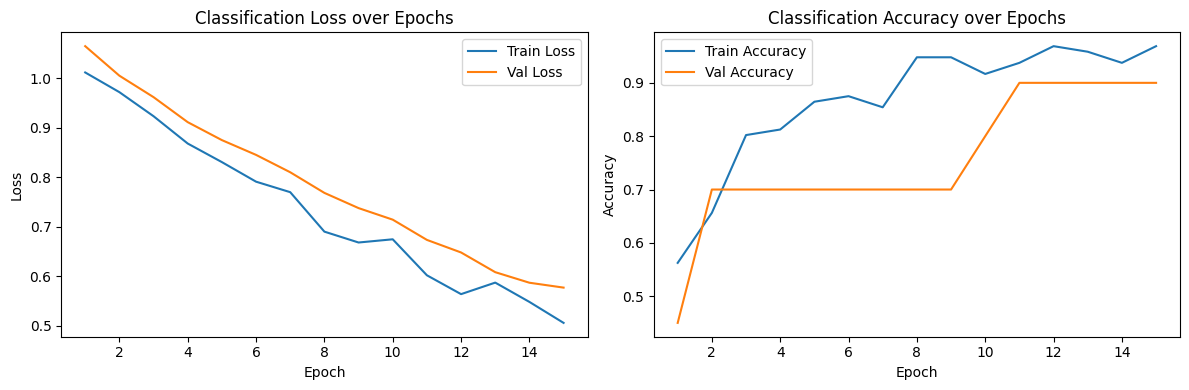

In [ ]:
# Plot training/validation loss and accuracy curves
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Classification Loss over Epochs"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Classification Accuracy over Epochs"); plt.legend()

plt.tight_layout()
plt.savefig("/content/classification_training_curves.png")
plt.show()

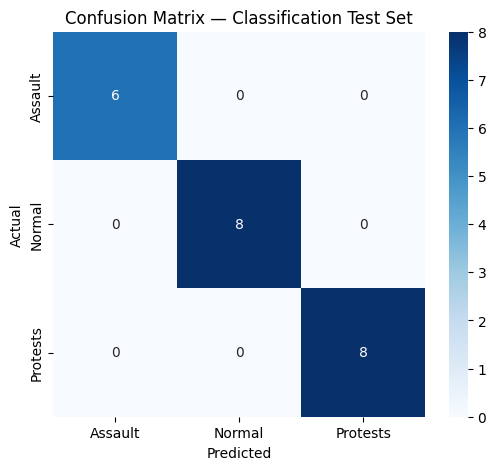

              precision    recall  f1-score   support

     Assault       1.00      1.00      1.00         6
      Normal       1.00      1.00      1.00         8
    Protests       1.00      1.00      1.00         8

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22

Model saved to Drive.


In [ ]:
# Evaluate on the held-out TEST set and plot a confusion matrix
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix — Classification Test Set")
plt.savefig("/content/classification_confusion_matrix.png")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

# Save the trained model back to your Drive
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet50_classifier.pth")
print("Model saved to Drive.")